In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.notebook import trange, tqdm
import os
import random
from torch.utils.data import ConcatDataset
from LCNN_backend import LCNN
from moe_model import Classic_MOE
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from scipy.special import expit
import numpy as np
import torch.nn.functional as F
from utility.utility import *




**Dataset Directories**

In [2]:
# Number of file to pick in both training and development set  
# 
DATASET_MAP = {
    'asv2019': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_train_set_with_delta\\lfcc_tensors_train_set_with_delta',
        'dev': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_dev_set_with_delta\\lfcc_tensors_dev_set_with_delta',
        'eval': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_eval_set_with_delta\\lfcc_tensors_eval_set_with_delta'
    },
    'add2022': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_train',
        'dev':   'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_dev',
        'eval': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_eval',
    },
    'itw': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\itw_lfcc_with_delta',
    }
}                                                  


**Process training data**

In [3]:
random_seed = 42
COMBINED = False # True: all datasets, False: ASV only
train_files_pool = []
dev_files_pool = []


# --- File Compilation Engine ---
if COMBINED:
    for key, paths in DATASET_MAP.items():
        if key != 'itw':
            train_files_pool.extend(get_pt_files(paths['train']))
            dev_files_pool.extend(get_pt_files(paths['dev']))
        else:
            # Handle ITW split scenario cleanly
            all_itw = get_pt_files(paths['train'])
            itw_train, itw_dev = train_test_split(all_itw, test_size=0.4, random_state=random_seed)
            itw_dev, _ = train_test_split(itw_dev, test_size=0.5, random_state=random_seed)
            
            train_files_pool.extend(itw_train)
            dev_files_pool.extend(itw_dev)
    print("The combined datasets have been successfully compiled.")
else:
    asv_paths = DATASET_MAP['asv2019'] 
    train_files_pool = get_pt_files(asv_paths['train'])
    dev_files_pool = get_pt_files(asv_paths['dev'])
    print("The ASV-only datasets have been successfully compiled.")

print(f"Total compiled training files: {len(train_files_pool)}")
print(f"Total compiled validation files: {len(dev_files_pool)}")

# --- Unified DataLoader Initialization ---
train_dataset = MultiDatasetLoader(train_files_pool)
dev_dataset = MultiDatasetLoader(dev_files_pool)

dataLoader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False, pin_memory=True)

The ASV-only datasets have been successfully compiled.
Total compiled training files: 25380
Total compiled validation files: 24844


In [4]:
sample_feat, train_labels = collect_labels(dataLoader)

print("Example of one train feature shape:", sample_feat.shape)
print("Training label distribution:", torch.bincount(train_labels))

Example of one train feature shape: torch.Size([120, 126])
Training label distribution: tensor([22800,  2580])


**Set up moe model and hyperparameters**

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

asv_checkpoint_path = "C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\teamlab-phonetics\\advanced_baseline_model\\lcnn_asv_checkpoint.pth"
itw_checkpoint_path = "C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\teamlab-phonetics\\advanced_baseline_model\\lcnn_itw_checkpoint.pth"
add_checkpoint_path = "C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\teamlab-phonetics\\advanced_baseline_model\\lcnn_add_checkpoint.pth"

expert1 = LCNN()  
expert2 = LCNN()  
expert3 = LCNN()  
    
# Load the trained weights
asv_checkpoint = torch.load(asv_checkpoint_path, map_location=device, weights_only=False)
itw_checkpoint = torch.load(itw_checkpoint_path, map_location=device, weights_only=False)
add_checkpoint = torch.load(add_checkpoint_path, map_location=device, weights_only=False)

expert1.load_state_dict(asv_checkpoint['model_state_dict'])
expert2.load_state_dict(itw_checkpoint['model_state_dict'])
expert3.load_state_dict(add_checkpoint['model_state_dict'])

expert1.train()
expert2.train()
expert3.train()

moe_model = Classic_MOE(experts=[expert1, expert2, expert3], feature_shape=[120,126])
moe_model.to(device)


cuda


Classic_MOE(
  (experts): ModuleList(
    (0-2): 3 x LCNN(
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv1): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (maxpool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (conv4): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (batchnorm6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv7): Conv2d(32, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (maxpool9): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (batchnorm10): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv11): Conv2d(48, 96, kernel_size=(1, 1), stride=(1, 1))
      (batchnorm13): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv14): Conv2d(48, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (max

**Set up criterion, optimizer, scheduler**

In [6]:

# Proportion of samples of the training set
combined_counts = torch.bincount(train_labels) # tensor with [SPOOF, BONAFIDE]
combined_proportions = combined_counts / len(train_labels) * 100
combined_prop_spoof = float(combined_proportions[0])
combined_prop_bonafide = float(combined_proportions[1])
print("Proportion of the Training Set:\n",f"Spoof: {combined_prop_spoof:.2f}% | Bonafide: {combined_prop_bonafide:.2f}%")


class_weights = len(train_labels) / (combined_counts.float() * 2)

class_weights = torch.tensor(class_weights)
print("Weight tensor to be passed to the Loss Function", class_weights)


Proportion of the Training Set:
 Spoof: 89.83% | Bonafide: 10.17%
Weight tensor to be passed to the Loss Function tensor([0.5566, 4.9186])


C:\Users\Zheng\AppData\Local\Temp\ipykernel_1704\2052893924.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weights = torch.tensor(class_weights)


In [7]:
moe_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))  
#moe_criterion = nn.CrossEntropyLoss()

In [8]:
# moe_optimizer = torch.optim.AdamW(moe_model.parameters(), lr=1e-4, weight_decay=1e-3)  # Learning rate + weight decay
moe_optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, moe_model.parameters()), lr=1e-4, weight_decay=1e-5)
#scheduler = CosineAnnealingLR(moe_optimizer, T_max=100, eta_min=1e-5)
moe_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(moe_optimizer, T_max=100, eta_min=1e-5)

In [9]:
# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []


# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 15  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping
best_threshold = 0.0



**Training Loop**

In [10]:
def init_moe_weights(m):
    # Target only the linear gating network layers
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

# Apply the custom random initialization to the gating weights
moe_model.gating_network.apply(init_moe_weights)

Linear(in_features=15120, out_features=3, bias=True)

In [11]:
num_epochs = 150

# --- Initialize tracking pools ---
expert_1_history = []
expert_2_history = []
expert_3_history = []

# --- Training Loop ---
for epoch in range(num_epochs):
    moe_model.train()
    epoch_loss_train = 0.0
    correct_train, total_train = 0, 0

    for features, labels in dataLoader:
        features, labels = features.to(device), labels.to(device)
        
        outputs, gating_weights = moe_model(features)

        class_loss = moe_criterion(outputs, labels)
        balance_loss = calculate_gating_balance_loss(gating_weights) # avoid expert collapse
        total_loss = class_loss + 0.35 * balance_loss

        moe_optimizer.zero_grad()
        total_loss.backward()
        moe_optimizer.step()

        epoch_loss_train += total_loss.item()
        predicted = outputs.argmax(dim=1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

# --- Validation ---
    moe_model.eval()
    epoch_loss_val = 0.0
    correct_val, total_val = 0, 0
    all_scores, all_labels = [], []

    epoch_gating_weights = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)

            outputs, gating_weights = moe_model(features)
            loss = moe_criterion(outputs, labels)

            epoch_loss_val += loss.item()
            predicted = outputs.argmax(dim=1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
            probabilities = F.softmax(outputs, dim=1)
            all_scores.extend(probabilities[:, 1].cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

            epoch_gating_weights.extend(gating_weights.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    epoch_gating_weights = np.array(epoch_gating_weights)  # Shape: [Total_Val_Samples, Num_Experts]
    mean_allocations = np.mean(epoch_gating_weights, axis=0)

    expert_1_history.append(mean_allocations[0])
    expert_2_history.append(mean_allocations[1])
    expert_3_history.append(mean_allocations[2])

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}% | "
          f"Val Threshold: {threshold_val:.2f} | "
          f"Gate Allocations -> E1: {mean_allocations[0]*100:.1f}%, E2: {mean_allocations[1]*100:.1f}%, E3: {mean_allocations[2]*100:.1f}%")

    # Learning rate scheduling
    moe_scheduler.step()

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        best_threshold = threshold_val  # Save the threshold for best EER
        torch.save(moe_model.state_dict(), 'moe_delta_asv.pth')
        #torch.save(expert1.state_dict(), 'moe_epoch20_eval_expert1.pth')
        #torch.save(expert2.state_dict(), 'moe_epoch20_eval_expert2.pth')
        print(f"New best model saved! EER: {eer_val:.2f}%")
        # Save the threshold to a file
        with open('moe_delta_asv.txt', 'w') as f:
            f.write(f"{best_threshold:.4f}")
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break
print(f"Training completed. Best EER: {best_eer:.2f}% with threshold: {best_threshold:.4f}")

Epoch [1/150] | Train Loss: 0.4316, Acc: 98.33% | Val Loss: 0.0644, Acc: 97.95% | Val EER: 1.23% | Val Threshold: 0.91 | Gate Allocations -> E1: 46.3%, E2: 14.0%, E3: 39.6%
New best model saved! EER: 1.23%
Epoch [2/150] | Train Loss: 0.0646, Acc: 99.35% | Val Loss: 0.0307, Acc: 99.15% | Val EER: 1.10% | Val Threshold: 0.31 | Gate Allocations -> E1: 35.1%, E2: 17.6%, E3: 47.3%
New best model saved! EER: 1.10%
Epoch [3/150] | Train Loss: 0.0180, Acc: 99.89% | Val Loss: 0.0501, Acc: 99.38% | Val EER: 1.27% | Val Threshold: 0.07 | Gate Allocations -> E1: 30.9%, E2: 23.4%, E3: 45.7%
EER not improved. Patience counter: 1/15
Epoch [4/150] | Train Loss: 0.0148, Acc: 99.93% | Val Loss: 0.0268, Acc: 99.70% | Val EER: 0.39% | Val Threshold: 0.05 | Gate Allocations -> E1: 37.4%, E2: 28.9%, E3: 33.7%
New best model saved! EER: 0.39%
Epoch [5/150] | Train Loss: 0.0135, Acc: 99.94% | Val Loss: 0.0290, Acc: 99.72% | Val EER: 0.55% | Val Threshold: 0.03 | Gate Allocations -> E1: 36.1%, E2: 30.0%, E3: 3

## Plot Results

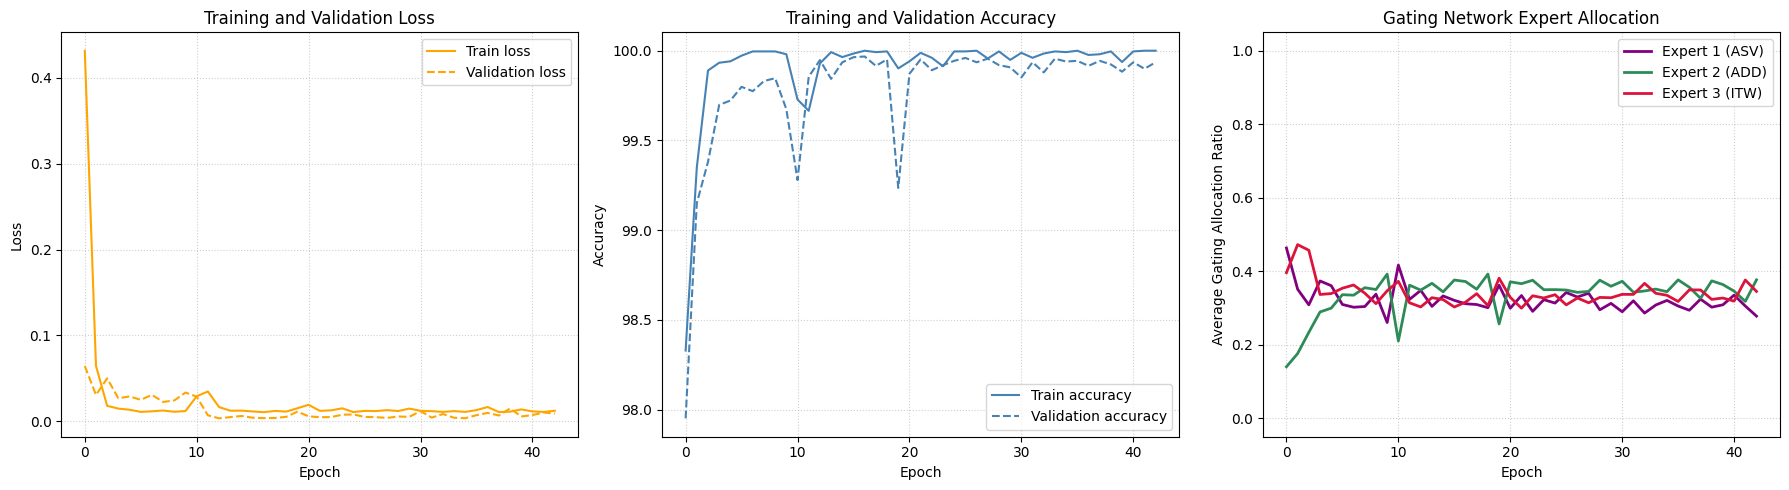

In [12]:
import matplotlib.pyplot as plt

# Expanded canvas size to fit all 3 plots horizontally
plt.figure(figsize=(18, 5))

# =====================================================================
# Subplot 1: Loss Plot
# =====================================================================
plt.subplot(1, 3, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# =====================================================================
# Subplot 2: Accuracy Plot
# =====================================================================
plt.subplot(1, 3, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# =====================================================================
# Subplot 3: Expert Weight Allocation Plot (NEW)
# =====================================================================
plt.subplot(1, 3, 3)
plt.plot(expert_1_history, color="purple", linestyle="-", linewidth=2, label="Expert 1 (ASV)")
plt.plot(expert_2_history, color="seagreen", linestyle="-", linewidth=2, label="Expert 2 (ADD)")
plt.plot(expert_3_history, color="crimson", linestyle="-", linewidth=2, label="Expert 3 (ITW)")
plt.xlabel("Epoch")
plt.ylabel("Average Gating Allocation Ratio")
plt.title("Gating Network Expert Allocation")
plt.ylim(-0.05, 1.05)  # Keeps the view scaled cleanly between 0.0 and 1.0
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

# Adjust spaces cleanly and display
plt.tight_layout()
plt.show()

**Prepare Evaluation dataset**

In [13]:


# Set the number of files to pick and the random seed
#random_seed = 42

target_eval_path = DATASET_MAP['asv2019']['eval']
target_eval_files = [f for f in os.listdir(target_eval_path) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(target_eval_path, target_eval_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in target_eval_files:
    file_path = os.path.join(target_eval_path, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=64, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")


Example of the .pt file tensor([[-3.1719e+02, -1.8039e+02, -6.8076e+01,  ..., -4.5134e+01,
         -3.8520e+01, -1.7389e+01],
        [ 8.4354e+01,  1.6613e+02,  2.0741e+02,  ...,  2.5119e+02,
          2.3634e+02,  2.3194e+02],
        [ 4.2919e+01,  3.2076e+01,  1.4553e+01,  ..., -4.7070e+00,
         -1.9970e+00, -8.4831e-02],
        ...,
        [ 1.7571e-02,  1.7571e-02,  1.7571e-02,  ...,  2.3086e-01,
          2.3086e-01,  2.3086e-01],
        [-4.9345e-01, -4.9345e-01, -4.9345e-01,  ...,  2.9802e-01,
          2.9802e-01,  2.9802e-01],
        [-1.0044e-01, -1.0044e-01, -1.0044e-01,  ...,  5.3810e-02,
          5.3810e-02,  5.3810e-02]])
Example of the features tensor([[-3.3888e+02, -3.7314e+02, -2.9060e+02,  ..., -3.8714e+02,
         -3.9049e+02, -3.9146e+02],
        [ 3.6489e+01,  3.1510e+01,  9.5408e+01,  ...,  2.2135e+01,
          1.7525e+01,  1.6173e+01],
        [ 1.3734e+01,  1.6058e+01,  4.1746e+01,  ...,  2.1536e+01,
          1.7273e+01,  1.5978e+01],
        ...

In [14]:
expert1 = LCNN()  
expert2 = LCNN()  
expert3 = LCNN()  

moe_model = Classic_MOE(experts=[expert1, expert2, expert3], feature_shape=[120,126])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load('moe_delta_asv.pth', map_location=device, weights_only=False)
moe_model.load_state_dict(checkpoint)

moe_model.to(device)

Classic_MOE(
  (experts): ModuleList(
    (0-2): 3 x LCNN(
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv1): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (maxpool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (conv4): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (batchnorm6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv7): Conv2d(32, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (maxpool9): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (batchnorm10): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv11): Conv2d(48, 96, kernel_size=(1, 1), stride=(1, 1))
      (batchnorm13): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv14): Conv2d(48, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (max


Evaluation Set:
Loss: 1.4751 | Accuracy: 76.68%
EER: 9.81% | Threshold used: 1.0000
F1 Score: 0.6543
Precision: 0.5133
Recall: 0.9022
Predictions: [1]: 12929 | [0]: 58308


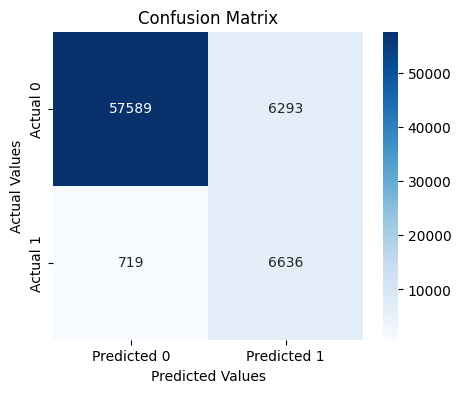

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
import numpy as np
import torch.nn.functional as F


num_epochs = 150


def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs, _ = model(features)
            loss = moe_criterion(outputs, labels.long())

            total_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            probabilities = F.softmax(outputs, dim=1)
            all_scores.extend(probabilities[:, 1].cpu().numpy())  # Use probability of positive class
            all_labels.extend(labels.cpu().numpy())

    # Convert to NumPy arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(all_labels, all_scores)
    preds = (all_scores >= threshold).astype(int)
    
    # Calculate precision and recall
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Threshold used: {threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(moe_model, eval_dataLoader)